Cell 1 — Install Required Libraries

In [ ]:
!pip install kagglehub networkx pandas matplotlib

Cell 2 — Download Dataset from KaggleHub

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("divyanshrai/openflights-airports-database-2017")

print("Dataset path:", path)

Using Colab cache for faster access to the 'openflights-airports-database-2017' dataset.
Dataset path: /kaggle/input/openflights-airports-database-2017


Cell 3 — Inspect Files in Dataset

In [ ]:
import os

print("Files inside dataset folder:")
for file in os.listdir(path):
    print(file)

Files inside dataset folder:
airports.csv


Cell 4 — Load Dataset

In [ ]:
import pandas as pd
import os

airports_file = os.path.join(path, "airports.csv")

airports = pd.read_csv(airports_file)

print("Dataset shape:", airports.shape)
airports.head()

Dataset shape: (7698, 14)


,Airport ID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Database Timezone,Type,Source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports


In [ ]:
print(airports.columns)

Index(['Airport ID', 'Name', 'City', 'Country', 'IATA', 'ICAO', 'Latitude',
       'Longitude', 'Altitude', 'Timezone', 'DST', 'Database Timezone', 'Type',
       'Source'],
      dtype='object')


Cell 3 — Data Preprocessing

In [ ]:
airports = airports.dropna(subset=["Latitude", "Longitude"])
airports = airports[airports["IATA"] != "\\N"]

print("Valid airports:", len(airports))

Valid airports: 6072


Cell 4 — Reduce Dataset Size

In [ ]:
airports = airports.head(30)

print("Airports selected:", len(airports))

Airports selected: 30


Cell 5 — Compute Distance Between Airports

In [ ]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    return R * c

Cell 6 — Create Graph

In [ ]:
import networkx as nx

G = nx.Graph()

for i in range(len(airports)):
    for j in range(i+1, len(airports)):

        lat1 = airports.iloc[i]["Latitude"]
        lon1 = airports.iloc[i]["Longitude"]

        lat2 = airports.iloc[j]["Latitude"]
        lon2 = airports.iloc[j]["Longitude"]

        dist = haversine(lat1, lon1, lat2, lon2)

        node1 = airports.iloc[i]["IATA"]
        node2 = airports.iloc[j]["IATA"]

        G.add_edge(node1, node2, weight=dist)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 30
Edges: 435


Cell 7 — BFS Connectivity

In [ ]:
source = list(G.nodes())[0]

visited = list(nx.bfs_tree(G, source))

print("BFS starting node:", source)
print("Visited nodes:", len(visited))

if len(visited) == G.number_of_nodes():
    print("Network is fully connected")
else:
    print("Network has disconnected components")

BFS starting node: GKA
Visited nodes: 30
Network is fully connected


Cell 8 — Dijkstra Shortest Path

In [ ]:
import random

nodes = list(G.nodes())

src = random.choice(nodes)
dst = random.choice(nodes)

path = nx.shortest_path(G, src, dst, weight="weight")
distance = nx.shortest_path_length(G, src, dst, weight="weight")

print("Source:", src)
print("Destination:", dst)
print("Shortest path:", path)
print("Distance:", round(distance,2),"km")

Source: HZK
Destination: MAG
Shortest path: ['HZK', 'MAG']
Distance: 13134.96 km


Cell 9 — All Pairs Shortest Path

In [ ]:
apsp = dict(nx.all_pairs_dijkstra_path_length(G))

print("Sample APSP distances")

for src in list(apsp.keys())[:5]:
    print(src, list(apsp[src].items())[:5])

Sample APSP distances
GKA [('GKA', 0), ('MAG', 106.7138992902682), ('HGU', 124.48104356917023), ('LAE', 157.10150462058704), ('WWK', 337.02254296786515)]
MAG [('MAG', 0), ('GKA', 106.7138992902682), ('HGU', 179.0359905939759), ('LAE', 183.5778989375171), ('WWK', 296.3425824280762)]
HGU [('HGU', 0), ('GKA', 124.48104356917023), ('MAG', 179.0359905939759), ('WWK', 258.90276087283536), ('LAE', 281.03737850795034)]
LAE [('LAE', 0), ('GKA', 157.10150462058704), ('MAG', 183.5778989375171), ('HGU', 281.03737850795034), ('POM', 324.1235525027357)]
POM [('POM', 0), ('LAE', 324.1235525027357), ('GKA', 424.5928070950016), ('MAG', 496.7781571354113), ('HGU', 515.2967960309529)]


Cell 10 — Network Metrics

In [ ]:
import numpy as np

lengths = []

for src in apsp:
    for dst in apsp[src]:
        if src != dst:
            lengths.append(apsp[src][dst])

avg_path = np.mean(lengths)
diameter = max(lengths)

print("Average shortest path:", round(avg_path,2),"km")
print("Network diameter:", round(diameter,2),"km")

Average shortest path: 5896.04 km
Network diameter: 14890.17 km


Cell 11 — Visualization

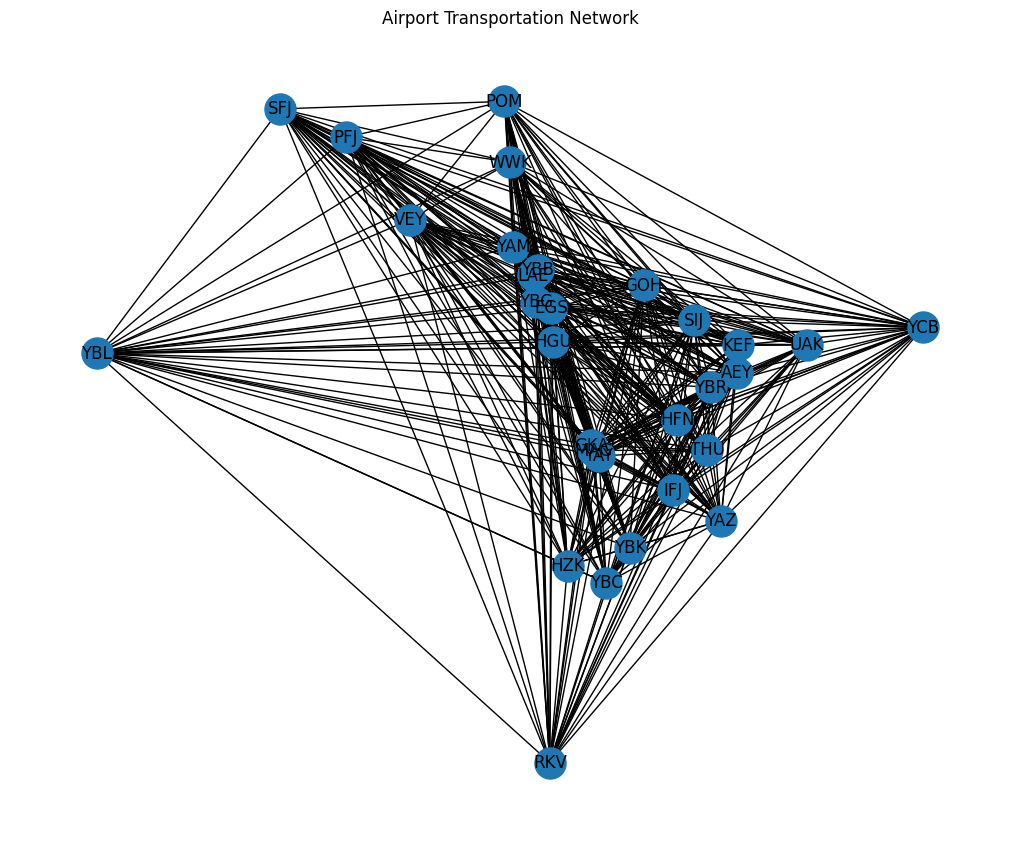

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G)

nx.draw(G, pos, node_size=500, with_labels=True)

plt.title("Airport Transportation Network")
plt.show()

Inferences

The airport network forms a highly connected transportation graph where several airports act as central hubs connecting multiple routes. Peripheral airports rely on these hubs for indirect connectivity. The dense edge structure indicates multiple routing possibilities, making shortest path algorithms essential for determining optimal travel routes.

Same methodology with different datasets


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vellis1/us-cities-urban-connectivity")

print("Path to dataset files:", path)

100%|██████████| 36.4k/36.4k [00:00<00:00, 26.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vellis1/us-cities-urban-connectivity/versions/5


In [ ]:
import os

print("Files in dataset folder:")
for file in os.listdir(path):
    print(file)

Files in dataset folder:
urban_connectivity.csv


Cell 1 — Load Dataset

In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "urban_connectivity.csv")

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (102, 79)


,Unnamed: 0,Place_name,City,State,Walk Score,Transit Score,Bike Score,Population_2021,Population_2022_Census,City_Population_Stats_adjusted_land_area__acres_,...,Number_of_Splashpads,Number_of_Swimming_pools,Number_of_Disc_Golf_Courses,Trail_Miles_Improved_Trails,Trail_Miles_Nature_trails,Number_of_Tracks_At_Park_Sites,Number_of_Tracks_At_community_schoolyards,Number_of_Exercise_Zones,Miles_of_car_free_roadways_in_parks,Permanent_car_free_roadways
0,0,"Los Angeles, CA",Los Angeles,CA,68.6,52.9,58.7,3792621,3903648.0,296527.0,...,17.0,64.0,4.0,33.00,33.0,1.0,0.0,133.0,0.0,0.0
1,1,"San Diego, CA",San Diego,CA,53.3,37.3,43.0,1307402,1394592.0,206371.0,...,4.0,14.0,3.0,66.20,292.8,0.0,50.0,8.0,0.0,0.0
2,2,"San Jose, CA",San Jose,CA,50.5,40.1,61.5,945942,1018924.0,112666.0,...,2.0,6.0,1.0,75.60,37.9,0.0,0.0,42.0,0.0,0.0
3,3,"San Francisco, CA",San Francisco,CA,88.7,77.1,72.3,805235,883822.0,29892.0,...,11.0,12.0,2.0,51.35,34.0,3.0,0.0,5.0,7.0,4.0
4,4,"Fresno, CA",Fresno,CA,46.6,33.1,58.1,494665,547499.0,72537.0,...,7.0,9.0,1.0,2.00,0.0,10.0,0.0,17.0,0.0,0.0


Cell 5 — Inspect Columns

In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'Place_name', 'City', 'State', 'Walk Score',
       'Transit Score', 'Bike Score', 'Population_2021',
       'Population_2022_Census',
       'City_Population_Stats_adjusted_land_area__acres_',
       'City_Population_Stats_density__people_acre_',
       'City_Population_Stats_density_classification',
       'City_Population_Stats_2000_population',
       'City_Population_Stats_population_growth',
       'City_Population_Stats_population_growth_classification',
       'Parkland_Stats_by_City_total_acres', 'Parkland_Stats_by_City__natural',
       'Parkland_Stats_by_City__designed',
       'Parkland_Stats_by_City_total_park_units',
       'Parkland_Stats_by_City_parks_as__city_area',
       'Walkable_Park_Access_all_residents', 'Walkable_Park_Access_black',
       'Walkable_Park_Access_hispanic_latinx', 'Walkable_Park_Access_asian',
       'Walkable_Park_Access_other_race',
       'Walkable_Park_Access_multiple_races',
       'Walkable_Park_Access_pacific_islander',

Cell - Select Important Columns

In [ ]:
df = df[[
    "City",
    "Walk Score",
    "Transit Score",
    "Bike Score"
]]

df = df.dropna()

print("Clean dataset size:", df.shape)
df.head()

Clean dataset size: (97, 4)


,City,Walk Score,Transit Score,Bike Score
0,Los Angeles,68.6,52.9,58.7
1,San Diego,53.3,37.3,43.0
2,San Jose,50.5,40.1,61.5
3,San Francisco,88.7,77.1,72.3
4,Fresno,46.6,33.1,58.1


Cell  — Reduce Dataset Size

In [ ]:
df = df.head(25)

print("Cities selected:", len(df))

Cities selected: 25


Cell  — Build Graph Using Score Similarity

In [ ]:
import networkx as nx

G = nx.Graph()

for i in range(len(df)):
    for j in range(i+1, len(df)):

        city1 = df.iloc[i]["City"]
        city2 = df.iloc[j]["City"]

        w1 = df.iloc[i]["Walk Score"]
        w2 = df.iloc[j]["Walk Score"]

        t1 = df.iloc[i]["Transit Score"]
        t2 = df.iloc[j]["Transit Score"]

        b1 = df.iloc[i]["Bike Score"]
        b2 = df.iloc[j]["Bike Score"]

        # distance between city mobility scores
        weight = abs(w1-w2) + abs(t1-t2) + abs(b1-b2)

        G.add_edge(city1, city2, weight=weight)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 25
Edges: 300


Cell  — BFS Connectivity

In [ ]:
source = list(G.nodes())[0]

visited = list(nx.bfs_tree(G, source))

print("Starting city:", source)
print("Visited cities:", len(visited))

if len(visited) == G.number_of_nodes():
    print("Network is fully connected")
else:
    print("Network has disconnected components")

Starting city: Los Angeles
Visited cities: 25
Network is fully connected


Cell  — Dijkstra Shortest Path

In [ ]:
import random

nodes = list(G.nodes())

src = random.choice(nodes)
dst = random.choice(nodes)

path = nx.shortest_path(G, src, dst, weight="weight")
distance = nx.shortest_path_length(G, src, dst, weight="weight")

print("Source:", src)
print("Destination:", dst)
print("Shortest path:", path)
print("Distance:", distance)

Source: Santa Ana
Destination: Sacramento
Shortest path: ['Santa Ana', 'Sacramento']
Distance: 32.199999999999996


  APSP

In [ ]:
apsp = dict(nx.all_pairs_dijkstra_path_length(G))

print("Sample APSP results:")

for src in list(apsp.keys())[:5]:
    print(src, list(apsp[src].items())[:5])

Sample APSP results:
Los Angeles [('Los Angeles', 0), ('Buffalo', np.float64(11.499999999999993)), ('Santa Ana', np.float64(14.600000000000001)), ('Oakland', np.float64(17.200000000000003)), ('Long Beach', np.float64(20.099999999999994))]
San Diego [('San Diego', 0), ('Chula Vista', np.float64(11.399999999999991)), ('Detroit', np.float64(12.899999999999991)), ('Spokane', np.float64(14.499999999999993)), ('Anaheim', np.float64(15.100000000000001))]
San Jose [('San Jose', 0), ('Fremont', np.float64(11.500000000000007)), ('Sacramento', np.float64(13.100000000000009)), ('Fresno', np.float64(14.299999999999997)), ('Detroit', np.float64(14.399999999999999))]
San Francisco [('San Francisco', 0), ('New York', np.float64(15.200000000000003)), ('Chicago', np.float64(23.69999999999999)), ('Seattle', np.float64(32.99999999999999)), ('Oakland', np.float64(40.699999999999996))]
Fresno [('Fresno', 0), ('Phoenix', np.float64(9.900000000000006)), ('Fremont', np.float64(10.199999999999996)), ('Spokane',

 Network Metrics

In [ ]:
import numpy as np

lengths = []

for src in apsp:
    for dst in apsp[src]:
        if src != dst:
            lengths.append(apsp[src][dst])

print("Average shortest path:", np.mean(lengths))
print("Network diameter:", max(lengths))

Average shortest path: 46.66199999999999
Network diameter: 140.29999999999998


 Visualization

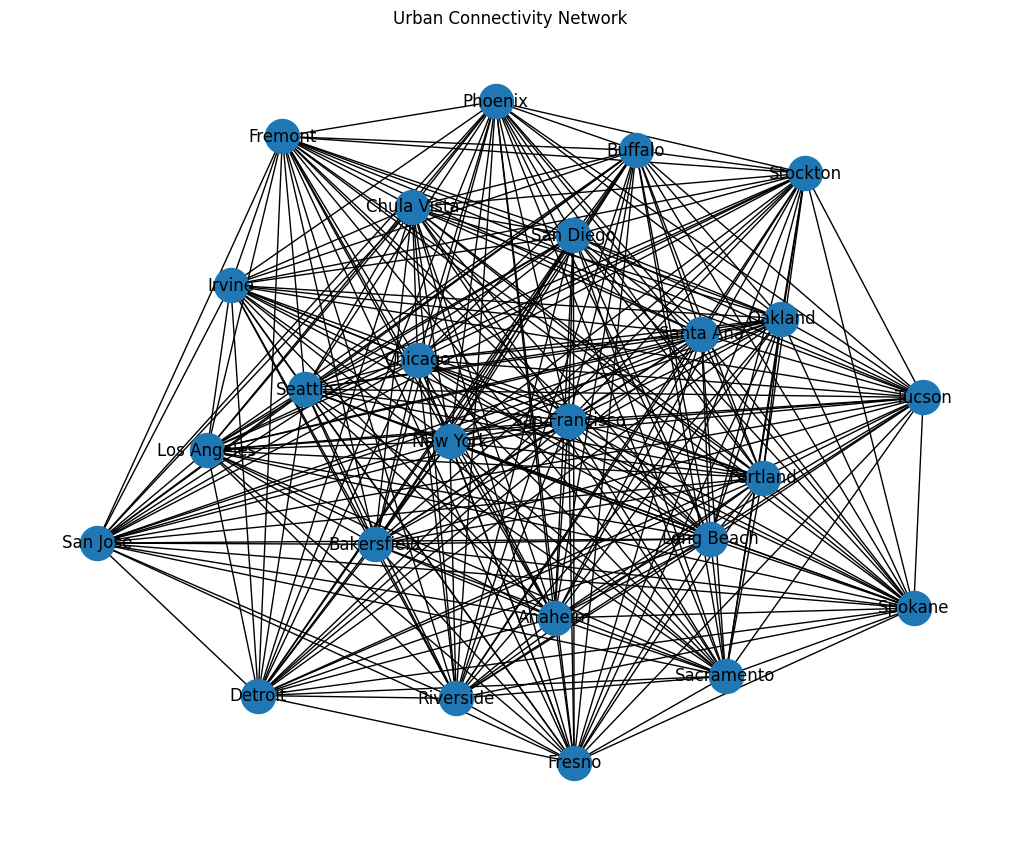

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=600)

plt.title("Urban Connectivity Network")
plt.show()

Inferences

The urban connectivity network shows a dense and fully connected graph where several cities act as central hubs connecting many others. Peripheral cities lie at the boundaries but still remain connected to the network. The high number of edges indicates multiple possible routes between cities, making shortest path algorithms essential for identifying optimal connections.

# real world example

In [ ]:
import pandas as pd

data = [
    ("New York", "Philadelphia", 150),
    ("New York", "Boston", 346),
    ("Philadelphia", "Washington", 225),
    ("Washington", "Richmond", 180),
    ("Richmond", "Charlotte", 480),
    ("Charlotte", "Atlanta", 400),
    ("Atlanta", "Nashville", 400),
    ("Nashville", "Chicago", 470),
    ("Chicago", "Detroit", 450),
    ("Detroit", "Cleveland", 170),
    ("Cleveland", "Pittsburgh", 135),
    ("Pittsburgh", "New York", 600),
]

df = pd.DataFrame(data, columns=["source", "destination", "distance"])
df.head()

,source,destination,distance
0,New York,Philadelphia,150
1,New York,Boston,346
2,Philadelphia,Washington,225
3,Washington,Richmond,180
4,Richmond,Charlotte,480


Cell 2 — Data Preprocessing

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Check for nulls
df = df.dropna()

print("Dataset size:", df.shape)

Dataset size: (12, 3)


Cell 3 — Graph Construction

In [ ]:
import networkx as nx

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row["source"], row["destination"], weight=row["distance"])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 12
Edges: 12


Cell 4 — BFS Connectivity Analysis

In [ ]:
from collections import deque

def bfs(graph, start):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.add(node)
            for neighbor in graph.neighbors(node):
                queue.append(neighbor)

    return visited

start_node = "New York"
visited = bfs(G, start_node)

print("Visited nodes:", visited)

if len(visited) == G.number_of_nodes():
    print("Network is fully connected")
else:
    print("Network is NOT fully connected")

Visited nodes: {'Charlotte', 'Chicago', 'Pittsburgh', 'Richmond', 'Washington', 'Nashville', 'Philadelphia', 'New York', 'Atlanta', 'Boston', 'Cleveland', 'Detroit'}
Network is fully connected


Cell 5 — Dijkstra Algorithm

In [ ]:
import heapq

def dijkstra(graph, source):
    dist = {node: float('inf') for node in graph.nodes()}
    dist[source] = 0
    prev = {node: None for node in graph.nodes()}

    pq = [(0, source)]

    while pq:
        current_dist, current_node = heapq.heappop(pq)

        for neighbor in graph.neighbors(current_node):
            weight = graph[current_node][neighbor]['weight']
            new_dist = current_dist + weight

            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist
                prev[neighbor] = current_node
                heapq.heappush(pq, (new_dist, neighbor))

    return dist, prev

def get_path(prev, target):
    path = []
    while target:
        path.append(target)
        target = prev[target]
    return path[::-1]

dist, prev = dijkstra(G, "New York")

target = "Chicago"
path = get_path(prev, target)

print("Shortest path:", path)
print("Distance:", dist[target])

Shortest path: ['New York', 'Pittsburgh', 'Cleveland', 'Detroit', 'Chicago']
Distance: 1355


Cell 6 — APSP using Floyd–Warshall

In [ ]:
def floyd_warshall(graph):
    nodes = list(graph.nodes())
    dist = {i: {j: float('inf') for j in nodes} for i in nodes}

    for node in nodes:
        dist[node][node] = 0

    for u, v, data in graph.edges(data=True):
        dist[u][v] = data['weight']
        dist[v][u] = data['weight']

    for k in nodes:
        for i in nodes:
            for j in nodes:
                dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])

    return dist

fw_dist = floyd_warshall(G)
print("Floyd-Warshall Sample:", list(fw_dist.items())[:1])

Floyd-Warshall Sample: [('New York', {'New York': 0, 'Philadelphia': 150, 'Boston': 346, 'Washington': 375, 'Richmond': 555, 'Charlotte': 1035, 'Atlanta': 1435, 'Nashville': 1825, 'Chicago': 1355, 'Detroit': 905, 'Cleveland': 735, 'Pittsburgh': 600})]


Cell 7 — APSP using Repeated Dijkstra

In [ ]:
dj_dist = {}

for node in G.nodes():
    dist, _ = dijkstra(G, node)
    dj_dist[node] = dist

print("Dijkstra APSP Sample:", list(dj_dist.items())[:1])

Dijkstra APSP Sample: [('New York', {'New York': 0, 'Philadelphia': 150, 'Boston': 346, 'Washington': 375, 'Richmond': 555, 'Charlotte': 1035, 'Atlanta': 1435, 'Nashville': 1825, 'Chicago': 1355, 'Detroit': 905, 'Cleveland': 735, 'Pittsburgh': 600})]


Cell 8 — Verify Both Algorithms

In [ ]:
mismatch = 0

for i in fw_dist:
    for j in fw_dist[i]:
        if fw_dist[i][j] != dj_dist[i][j]:
            mismatch += 1

print("Mismatch count:", mismatch)

Mismatch count: 0


Cell 9 — Network Metrics

In [ ]:
import numpy as np

values = []

for i in fw_dist:
    for j in fw_dist[i]:
        if i != j:
            values.append(fw_dist[i][j])

avg_path = np.mean(values)
diameter = max(values)

print("Average shortest path:", avg_path)
print("Network diameter:", diameter)

Average shortest path: 1009.3333333333334
Network diameter: 2171


Cell 10 — Visualization

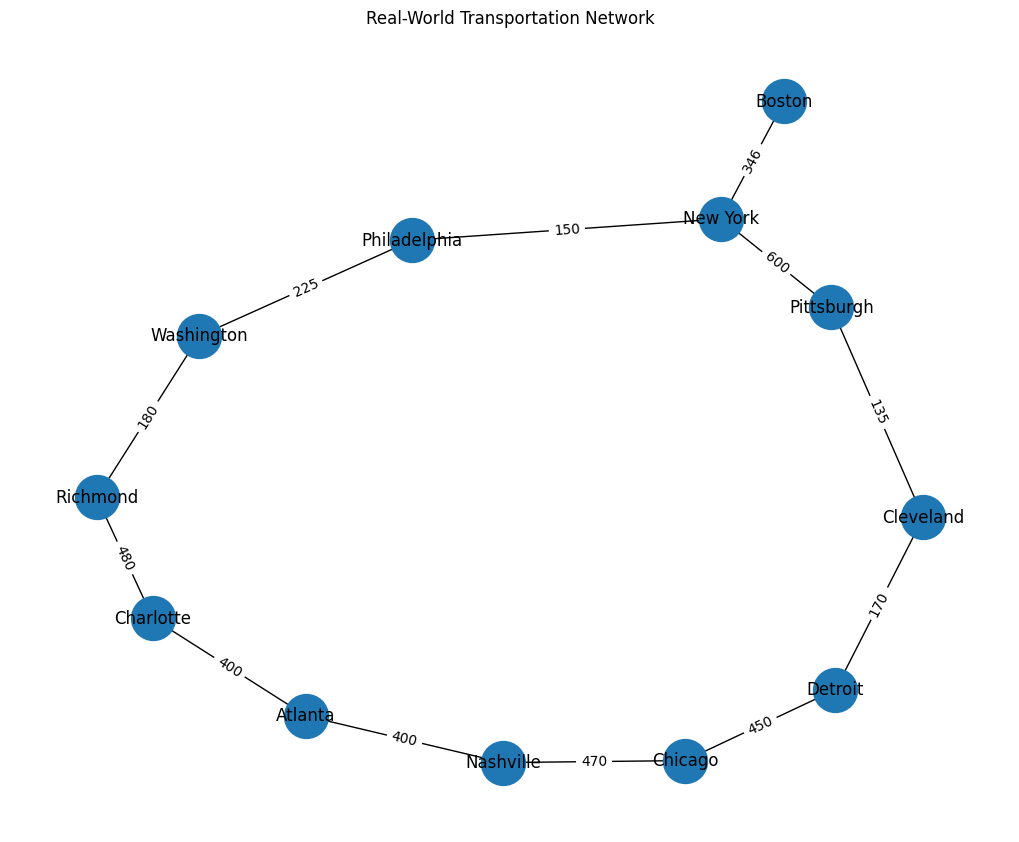

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=1000)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Real-World Transportation Network")
plt.show()

Inferences

The transportation network exhibits a sparse, geographically structured topology with critical intermediate nodes ensuring connectivity. The absence of redundant edges highlights realistic routing constraints, making shortest path algorithms essential for optimal navigation and cost-efficient transportation planning.